In [1]:
from sklearn.datasets import fetch_olivetti_faces
olivetti = fetch_olivetti_faces()
print(olivetti.DESCR)

.. _olivetti_faces_dataset:

The Olivetti faces dataset
--------------------------

`This dataset contains a set of face images`_ taken between April 1992 and
April 1994 at AT&T Laboratories Cambridge. The
:func:`sklearn.datasets.fetch_olivetti_faces` function is the data
fetching / caching function that downloads the data
archive from AT&T.

.. _This dataset contains a set of face images: https://cam-orl.co.uk/facedatabase.html

As described on the original website:

    There are ten different images of each of 40 distinct subjects. For some
    subjects, the images were taken at different times, varying the lighting,
    facial expressions (open / closed eyes, smiling / not smiling) and facial
    details (glasses / no glasses). All the images were taken against a dark
    homogeneous background with the subjects in an upright, frontal position
    (with tolerance for some side movement).

**Data Set Characteristics:**

=================   =====================
Classes              

In [2]:
olivetti.target

array([ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  3,  3,  3,  3,
        3,  3,  3,  3,  3,  3,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  5,
        5,  5,  5,  5,  5,  5,  5,  5,  5,  6,  6,  6,  6,  6,  6,  6,  6,
        6,  6,  7,  7,  7,  7,  7,  7,  7,  7,  7,  7,  8,  8,  8,  8,  8,
        8,  8,  8,  8,  8,  9,  9,  9,  9,  9,  9,  9,  9,  9,  9, 10, 10,
       10, 10, 10, 10, 10, 10, 10, 10, 11, 11, 11, 11, 11, 11, 11, 11, 11,
       11, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 13, 13, 13, 13, 13, 13,
       13, 13, 13, 13, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 15, 15, 15,
       15, 15, 15, 15, 15, 15, 15, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16,
       17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 18, 18, 18, 18, 18, 18, 18,
       18, 18, 18, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 20, 20, 20, 20,
       20, 20, 20, 20, 20, 20, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 22,
       22, 22, 22, 22, 22

In [3]:
X = olivetti.data
y = olivetti.target

In [4]:
import numpy as np
np.sqrt(4096) , X.shape # 차원이 4096

(np.float64(64.0), (400, 4096))

In [5]:
round(X[-1].min()), round(X[-1].max())

(0, 1)

In [6]:
# 데이터 분할
from collections import Counter
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test \
    = train_test_split(X,y,test_size=0.4,stratify=y,random_state=42)

In [7]:
# 연산속도 높이기  PCA
from sklearn.decomposition import PCA
pca = PCA(n_components=0.99)
x_train_pca =  pca.fit_transform(x_train)
x_test_pca = pca.transform(x_test)
pca.n_components_

np.int64(177)

In [8]:
# kmeans로 군집을 구분
# 최적의 k 개수
# DBSCAN
# 계층적 군집화

In [9]:
# k평균 군집화
# OMP_NUM_THREADS=1  환경셋팅
import os
os.environ["OMP_NUM_THREADS"] = '1'

c:\Users\Playdata\miniconda3\envs\test_env\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Playdata\miniconda3\envs\test_env\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Playdata\miniconda3\envs\test_env\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Playdata\miniconda3\envs\test_env\lib\site-packages\sklearn\cluster\_kmea

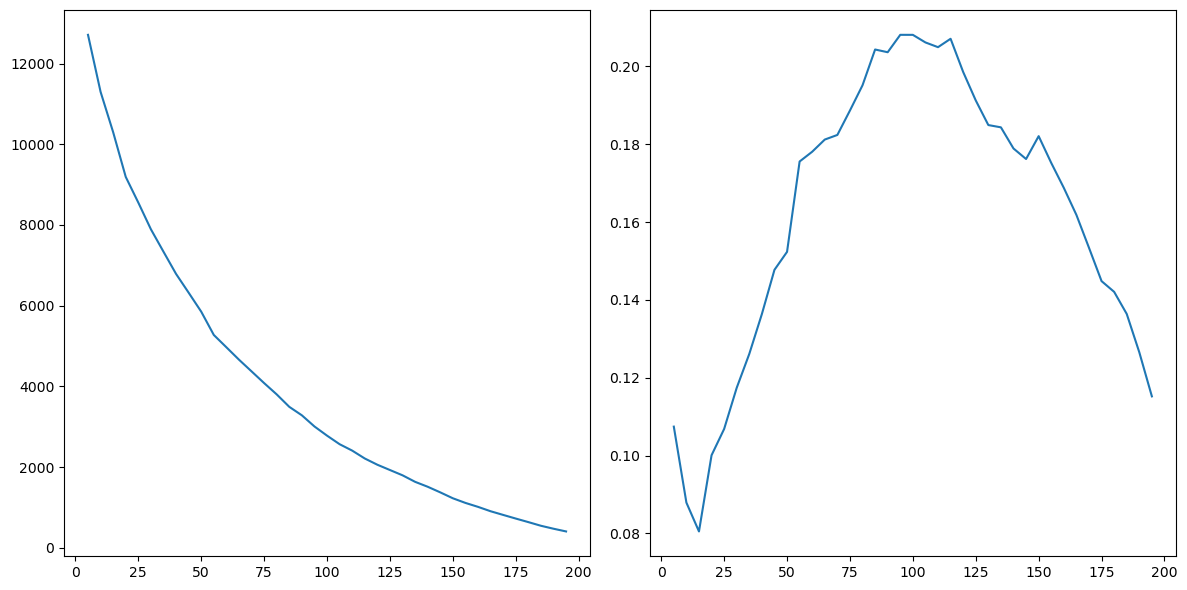

실루엣 최고점수의 인덱스 : 95


In [ ]:
    from sklearn.cluster import KMeans
    from sklearn.metrics import silhouette_score
    import matplotlib.pyplot as plt
    k_range = range(5,200,5)
    ellow = []
    sillhouet_scores = []
    for k in k_range:
        km = KMeans(n_clusters=k,random_state=42)
        km.fit(x_train_pca)
        
        sillhouet_scores.append(silhouette_score(x_train_pca, km.labels_))
        ellow.append(km.inertia_)

    fig, ax = plt.subplots(1,2,figsize=(12,6))
    ax[0].plot(k_range,ellow )
    ax[1].plot(k_range,sillhouet_scores)
    plt.tight_layout()
    plt.show()

    print(f'실루엣 최고점수의 인덱스 : {k_range[np.argmax(sillhouet_scores)] }')

(np.float64(-0.5), np.float64(63.5), np.float64(63.5), np.float64(-0.5))

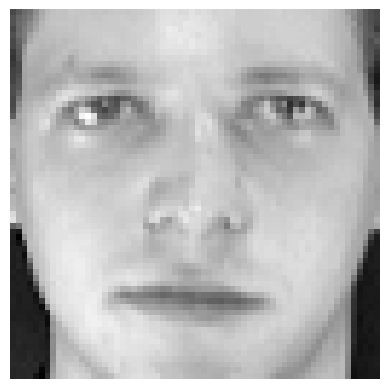

In [11]:
# 클러스터의 수 : 95
# 64 x 64
plt.imshow(X[0].reshape(64,64), cmap='gray')
plt.axis('off')

label = 0


c:\Users\Playdata\miniconda3\envs\test_env\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


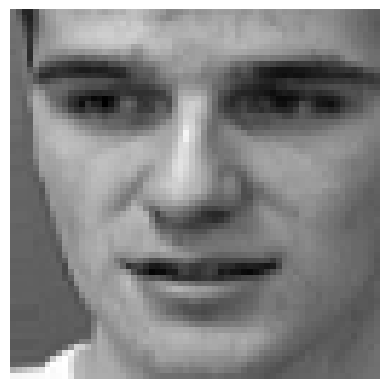

label = 1


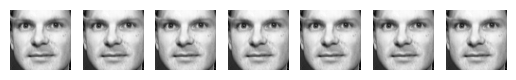

label = 2


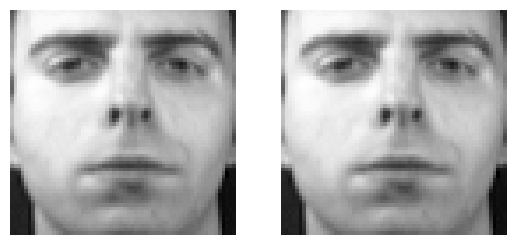

label = 3


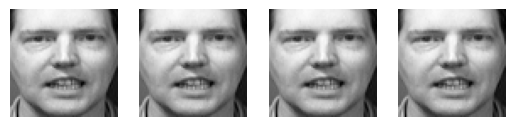

label = 4


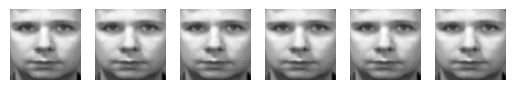

label = 5


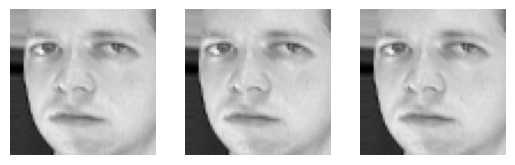

label = 6


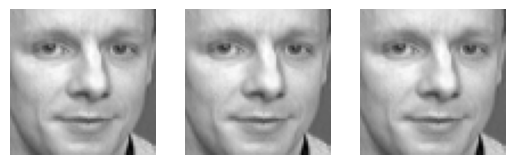

label = 7


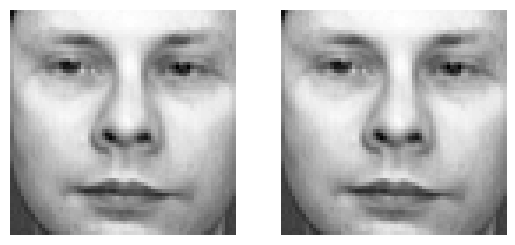

label = 8


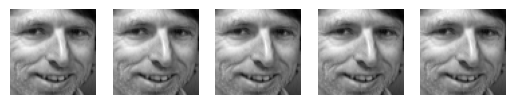

label = 9


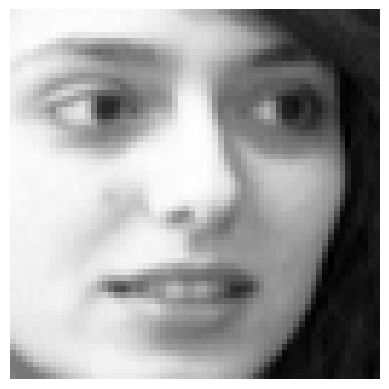

label = 10


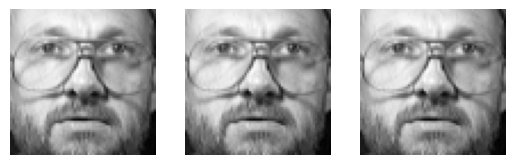

label = 11


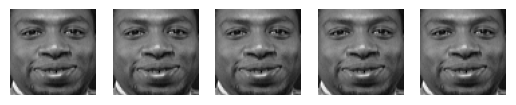

label = 12


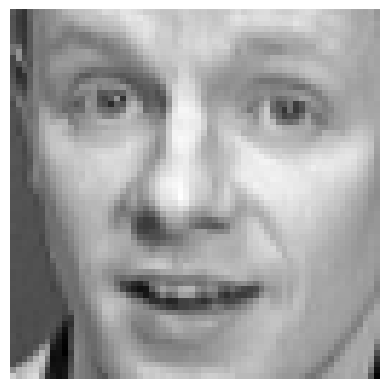

label = 13


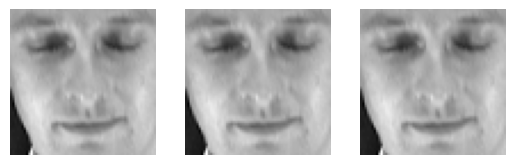

label = 14


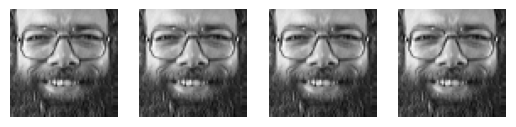

label = 15


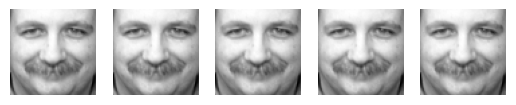

label = 16


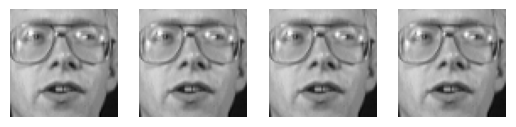

label = 17


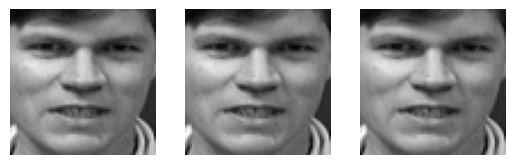

label = 18


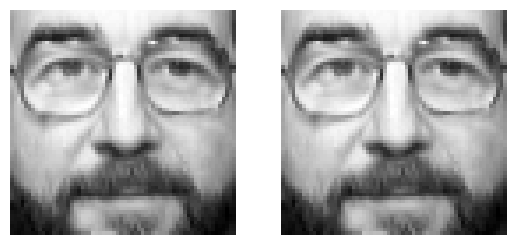

label = 19


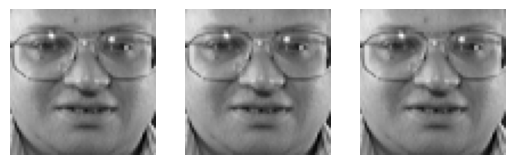

label = 20


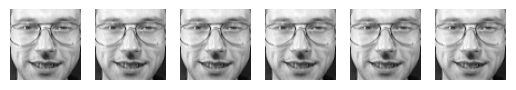

label = 21


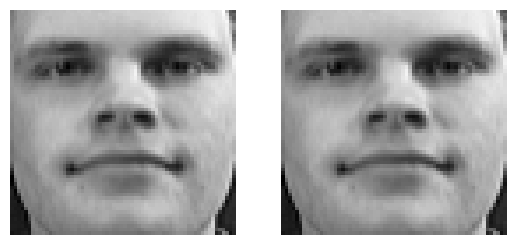

label = 22


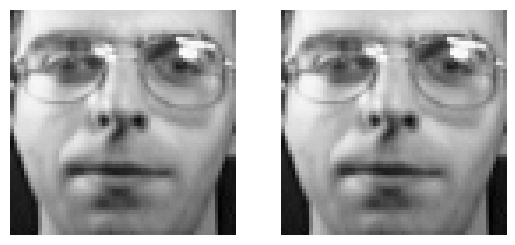

label = 23


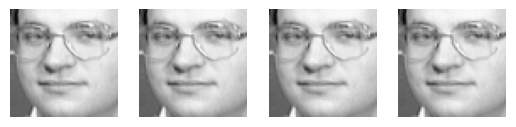

label = 24


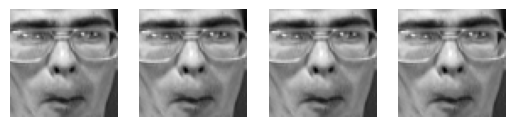

label = 25


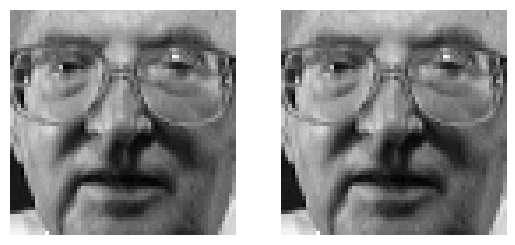

label = 26


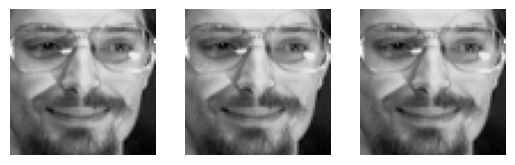

label = 27


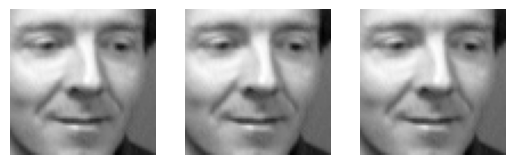

label = 28


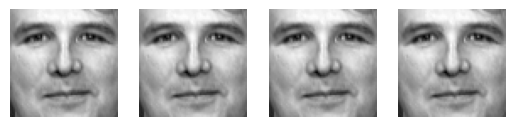

label = 29


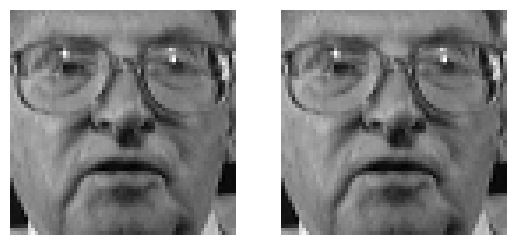

label = 30


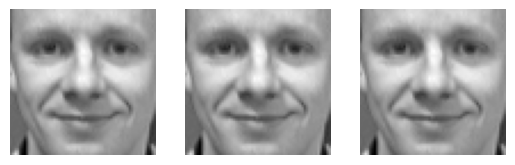

label = 31


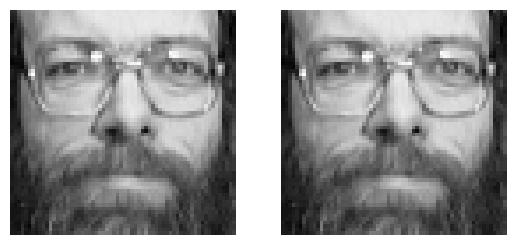

label = 32


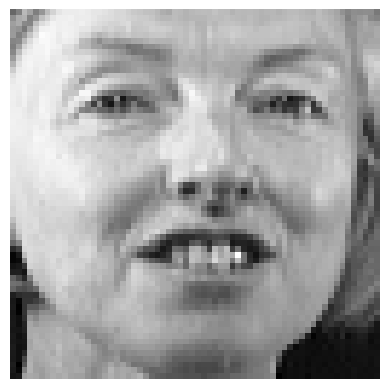

label = 33


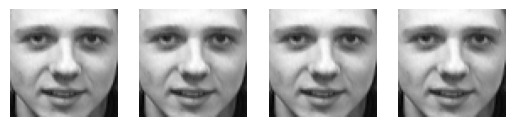

label = 34


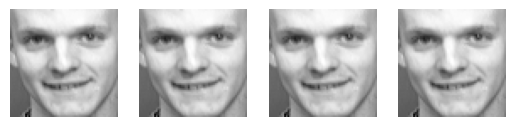

label = 35


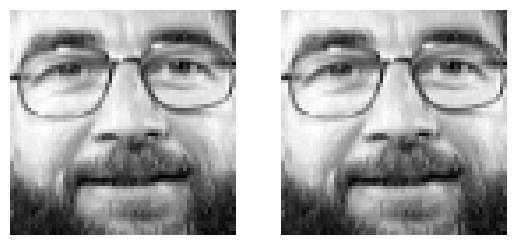

label = 36


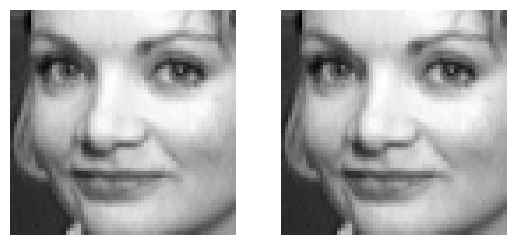

label = 37


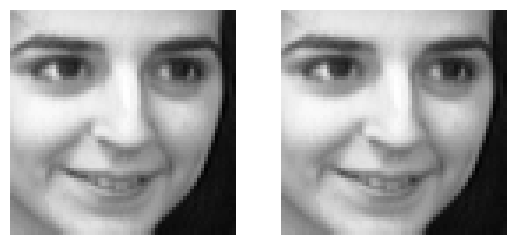

label = 38


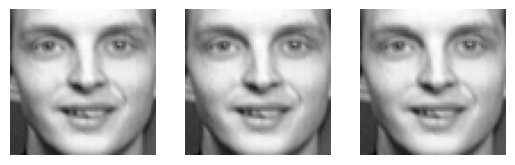

label = 39


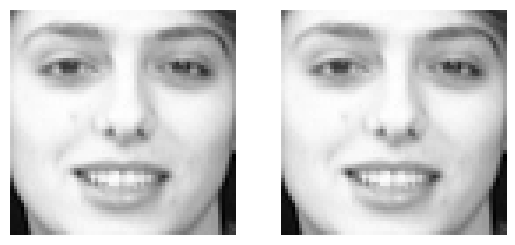

label = 40


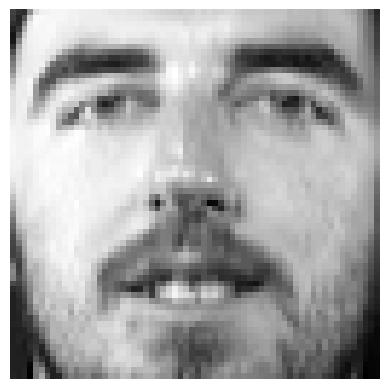

label = 41


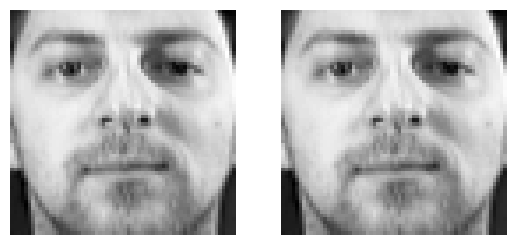

label = 42


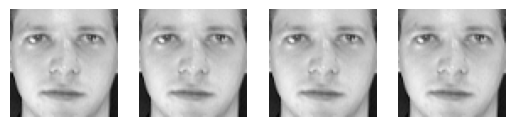

label = 43


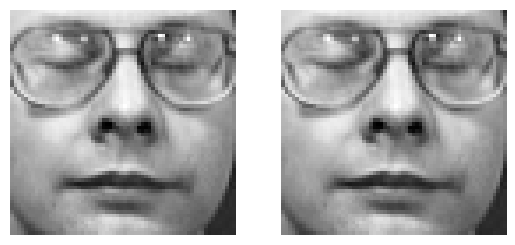

label = 44


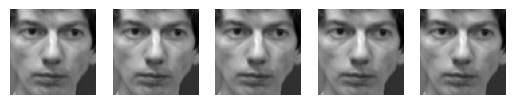

label = 45


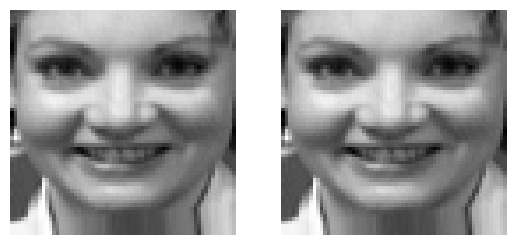

label = 46


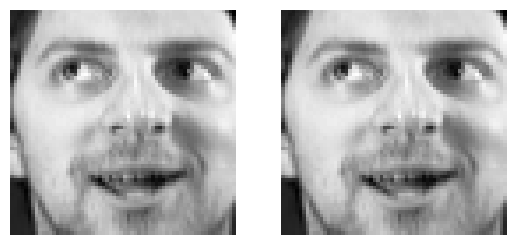

label = 47


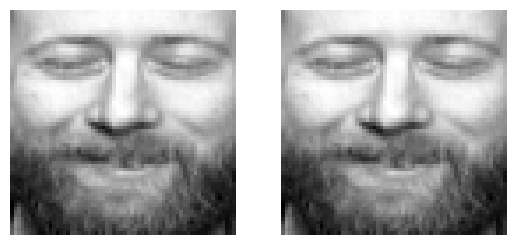

label = 48


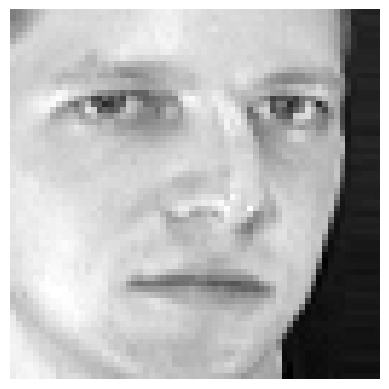

label = 49


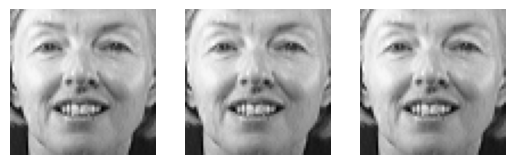

label = 50


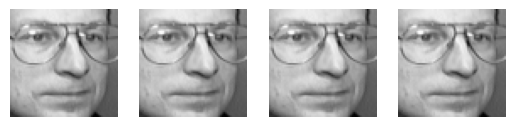

label = 51


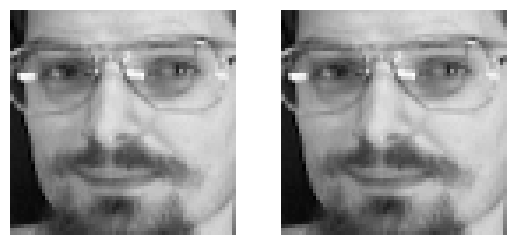

label = 52


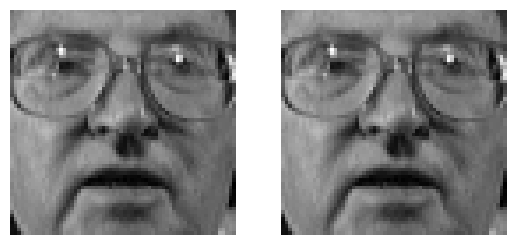

label = 53


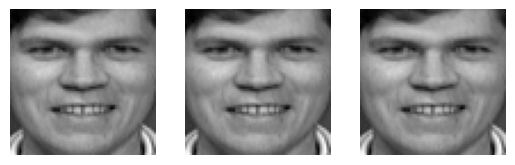

label = 54


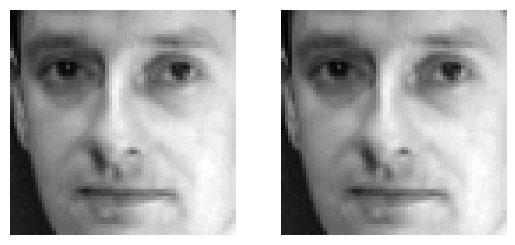

label = 55


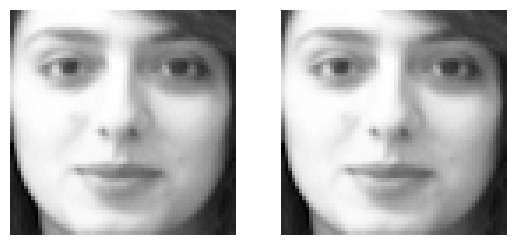

label = 56


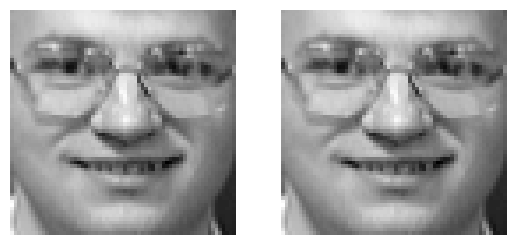

label = 57


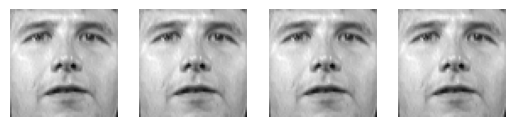

label = 58


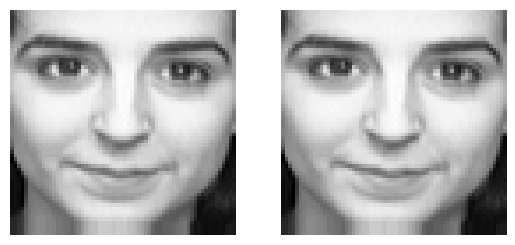

label = 59


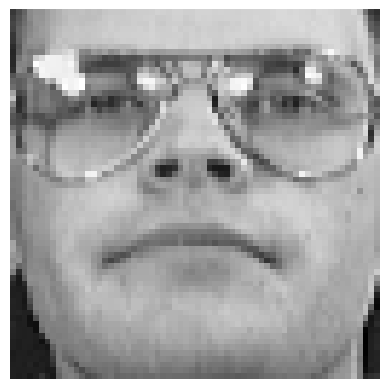

label = 60


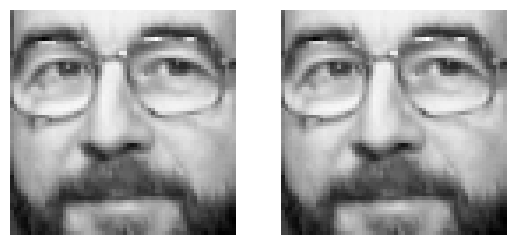

label = 61


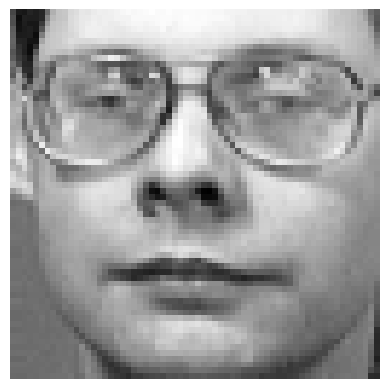

label = 62


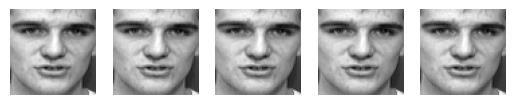

label = 63


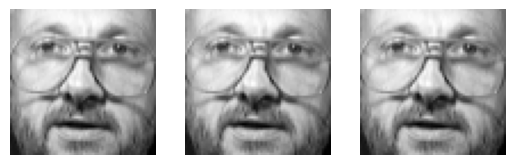

label = 64


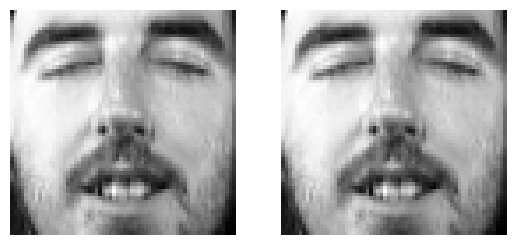

label = 65


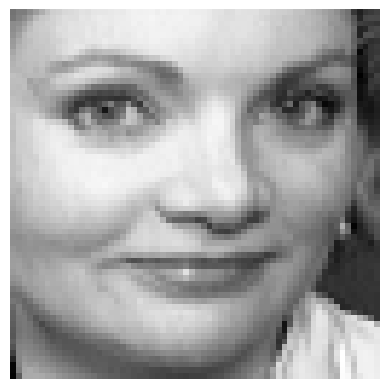

label = 66


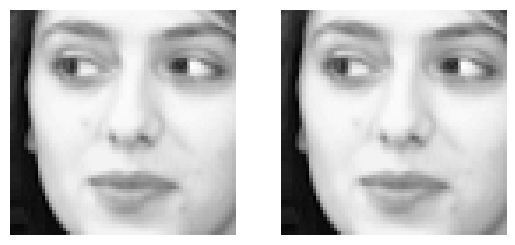

label = 67


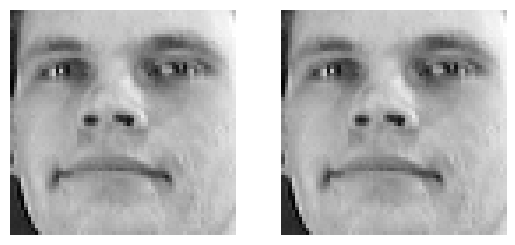

label = 68


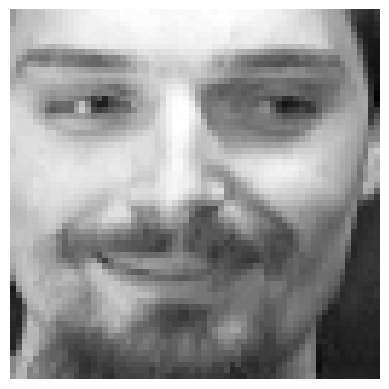

label = 69


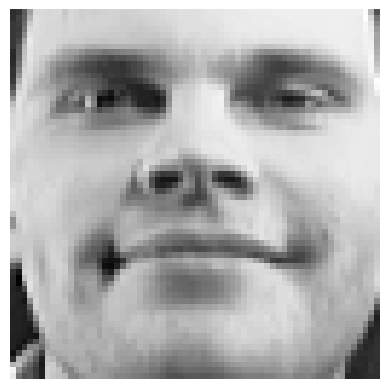

label = 70


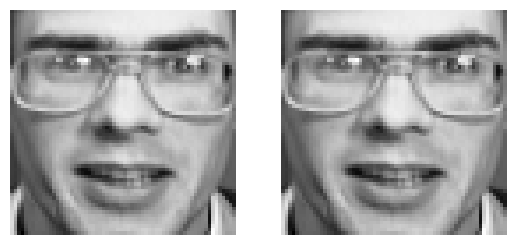

label = 71


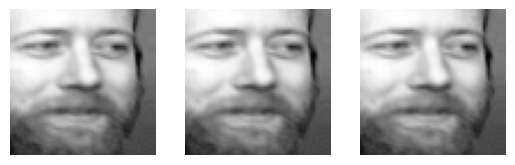

label = 72


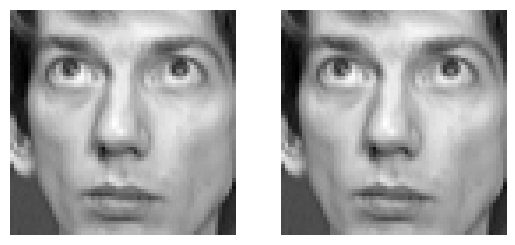

label = 73


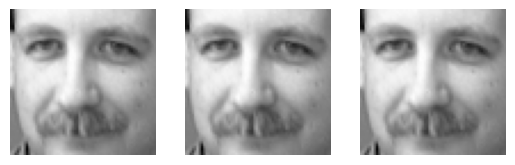

label = 74


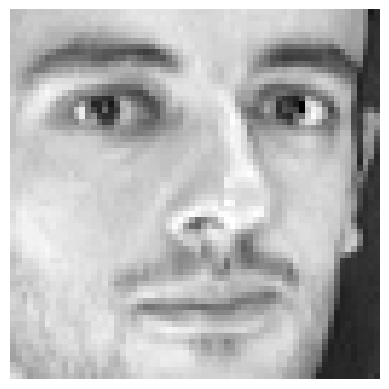

label = 75


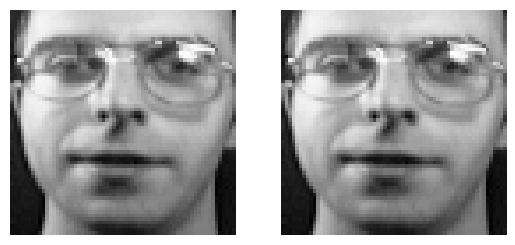

label = 76


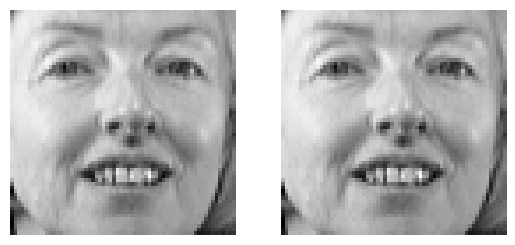

label = 77


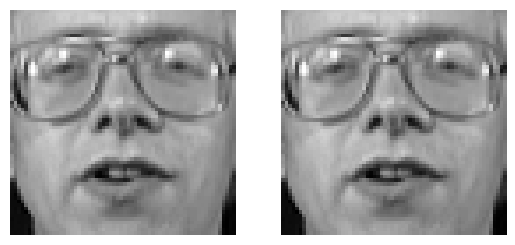

label = 78


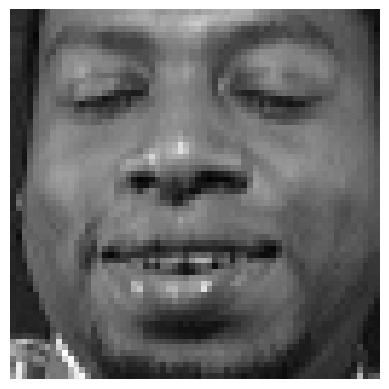

label = 79


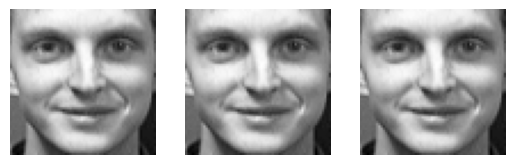

label = 80


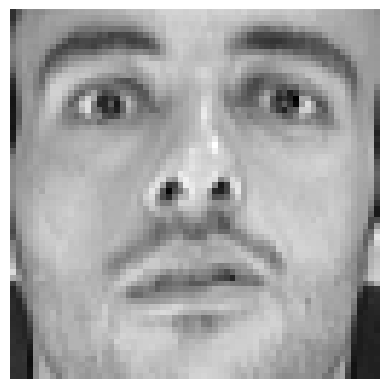

label = 81


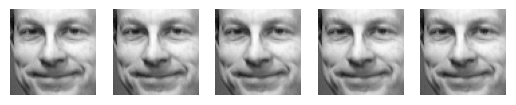

label = 82


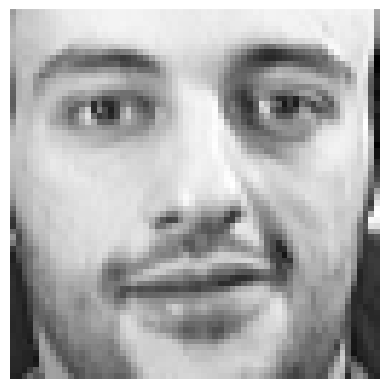

label = 83


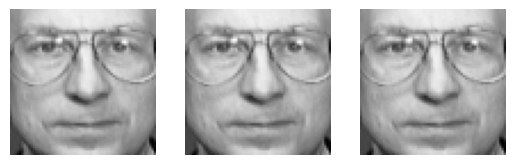

label = 84


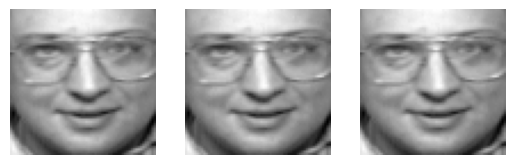

label = 85


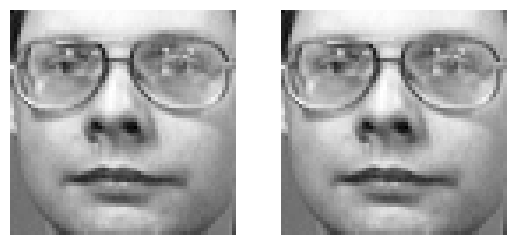

label = 86


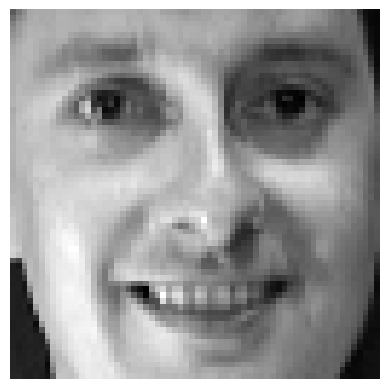

label = 87


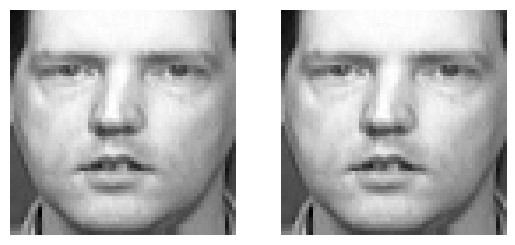

label = 88


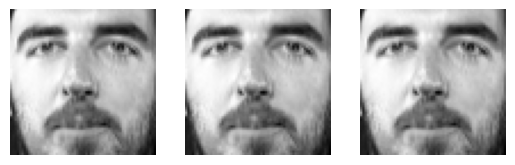

label = 89


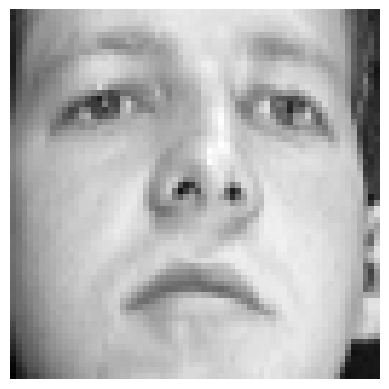

label = 90


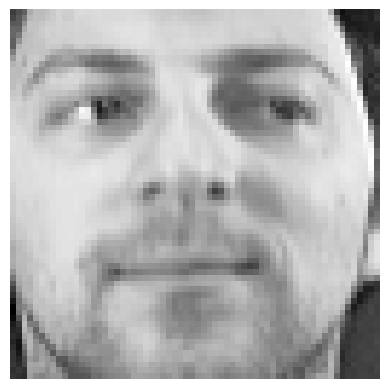

label = 91


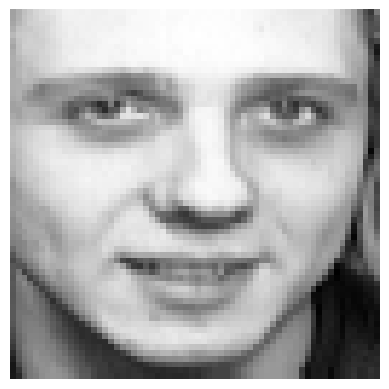

label = 92


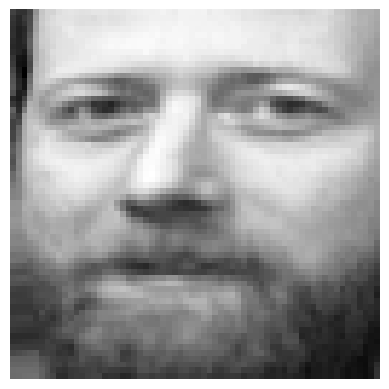

label = 93


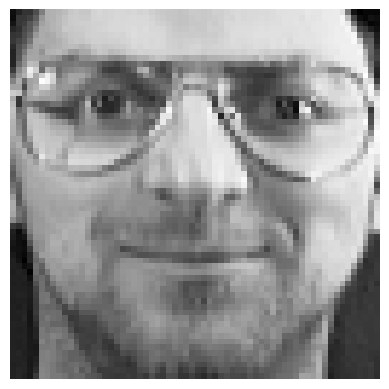

label = 94


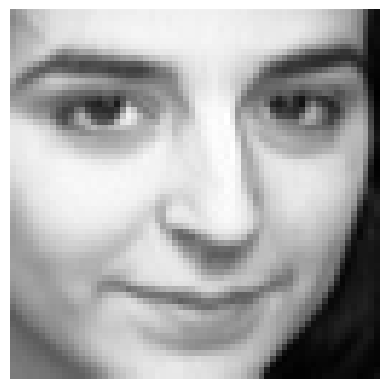

In [12]:
cluster = 95 
from sklearn.cluster import KMeans
km = KMeans(n_clusters=cluster,random_state=42)
km.fit(x_train_pca)

for c_label in np.unique(km.labels_):
    print(f'label = {c_label}')
    row_count = x_train[km.labels_ == c_label].shape[0]
    show_images = x_train[km.labels_ == c_label]
    
    for idx in range(row_count):
        plt.subplot(1,row_count,idx+1)
        plt.imshow(show_images[0].reshape(64,64),cmap='gray') 
        plt.axis('off')   
    plt.show()

In [13]:
# 분류기
from sklearn.ensemble import RandomForestClassifier
rfc = RandomForestClassifier(n_estimators=200, random_state=42)
rfc.fit(x_train_pca, y_train)
rfc.score(x_test_pca, y_test)

0.90625

In [14]:
# 새로운 라벨링 k 평균을 차원 축소 도구로 사용
x_train_reduced = km.transform(x_train_pca) # (pca, cluster)의 개수
x_test_reduced = km.transform(x_test_pca)
clf = RandomForestClassifier(n_estimators=200, random_state=42)
clf.fit(x_train_reduced,y_train)
clf.score(x_test_reduced,y_test)

0.73125

In [15]:
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
pipeline = Pipeline([
    ('pca',PCA(n_components=0.99, random_state=42)),
    ('cluster',KMeans(random_state=42)),
    ('rfc',RandomForestClassifier(n_estimators=200, random_state=42))
])
k_range = range(5, 200, 5)
scores = []
for k in k_range:
    pipeline.set_params(cluster__n_clusters=k)
    pipeline.fit(x_train,y_train)
    scores.append(pipeline.score(x_test,y_test))

max_index = np.argmax(scores)
print(f'정확도 : {np.max(scores)} 클러스터 개수 {k_range[max_index]}')

c:\Users\Playdata\miniconda3\envs\test_env\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Playdata\miniconda3\envs\test_env\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Playdata\miniconda3\envs\test_env\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Playdata\miniconda3\envs\test_env\lib\site-packages\sklearn\cluster\_kmea

정확도 : 0.78125 클러스터 개수 165


In [30]:
# dbscan
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test \
    = train_test_split(X,y,random_state=42,test_size=0.25,stratify=y)
pca = PCA(n_components=2,random_state=42)
x_train_pca = pca.fit_transform(x_train)
x_test_pca = pca.transform(x_test)
print(f'conponet : {pca.n_components_}')
dbscan = DBSCAN(eps=5, min_samples=5)
dbscan.fit(x_train_pca)
dbscan.labels_

conponet : 2


array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [31]:
from sklearn.cluster import AgglomerativeClustering
model_average = AgglomerativeClustering(n_clusters=5, linkage='average')

In [32]:
n_clusters = 100
import sklearn
from sklearn.cluster import AgglomerativeClustering
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
pca = PCA(n_components=0.99,random_state=42)
x_train_pca = pca.fit_transform(x_train)
x_test_pca = pca.transform(x_test)
model_average = AgglomerativeClustering(n_clusters=100, linkage='average')
y_train_pca_cluster = model_average.fit_predict(x_train_pca)
rfc = RandomForestClassifier(n_estimators=200,random_state=42)
rfc.fit(x_train_pca, y_train_pca_cluster)

y_test_predict = rfc.predict(x_test_pca)
rfc.score(x_test_pca, y_test_predict)

1.0